# Uncertanty Propagation MCDA
Here I test three approach to propagate the uncertanty in a MCDA framework

## Data Input

In [8]:
import numpy as np
from scipy.interpolate import PchipInterpolator

# Criteria names
criteria = ["C1", "C2", "C3", "C4"]

# Define alternatives
alternative_A = [9, (7, 0.7), [8, 8, 7], {2:3}]  # Criterion values for alternative A
alternative_B = [6, (6, 0.6), [7, 8, 6], {1:2}]  # Criterion values for alternative B
alternative_C = [2, (3, 0.3), [9, 6, 8], {3:6}]  # Criterion values for alternative C
alternatives = [alternative_A, alternative_B, alternative_C]

weights = [
    [(0.2, 0.25), (0.21, 0.26), (0.19, 0.24), (0.22, 0.27)],  # Criterion 1
    [(0.23, 0.3), (0.24, 0.31), (0.22, 0.29), (0.25, 0.32)],   # Criterion 2
    [(0.3, 0.4), (0.31, 0.41), (0.29, 0.39), (0.32, 0.42)],   # Criterion 3
    [(0.25, 0.35), (0.26, 0.36), (0.24, 0.34), (0.27, 0.37)]    # Criterion 4
]

# Results of value function elicitation
C1_vf_a_points = [0, 3, 5, 6, 10]
C1_vf_b_points = [0, 2, 4, 7, 10]
C2_vf_a_points = [0, 4, 6, 8, 10]
C2_vf_b_points = [0, 3, 5, 7, 10]
C3_vf_a_points = [0, 2, 7, 9, 10]
C3_vf_b_points = [0, 1, 6, 8, 10]
C4_vf_a_points = [0, 1, 4, 6, 10]
C4_vf_b_points = [0, 2, 5, 7, 10]

elicitation_values = [0, 0.25, 0.5, 0.75, 1]
def value_function(*points):
    x = np.linspace(0, 10, 100)
    value_functions = []
    for point in points:
        vf = PchipInterpolator(point, elicitation_values)
        value_functions.append(vf)

    return value_functions

vf_C1 = value_function(C1_vf_a_points, C1_vf_b_points)
vf_C2 = value_function(C2_vf_a_points, C2_vf_b_points)
vf_C3 = value_function(C3_vf_a_points, C3_vf_b_points)
vf_C4 = value_function(C4_vf_a_points, C4_vf_b_points)

vf_list = [vf_C1, vf_C2, vf_C3, vf_C4]

## MC-RSS Method
This method is primarly based on the error propagation by means of the root sum square method. To do so we assume all uncertanties can be expressed in the form $\mu \pm \sigma$, therefore assuming all distribution are normal distributions. The MC component is used to compute $v(x)$ since $x$, the input data, is normally distributed but we also have to consider that the value function $v$ return a normal distirbution for each input. For this we therefore sample by means of Montecarlo code to then assume the resulting distribution is again a normal one. 

The result is a very quick computation that returns the alternative value $A$ in terms of $\mu \pm \sigma$

In [ ]:
from up_mavt import mc_rss_mavt
results_MC_RSS = mc_rss_mavt(alternatives, vf_list, weights, mc_simulations=10000)

## Fully Montecarlo: NSMC and SMC Methods
Here we drop the previous hypotesis of normally distributed data to instead propagate the uncertanty as is.
The montecarlo approach has to variants: Non-Strict and Strict  
In the Non-Strict (NSMC) we create distributions based on the available data, under the assumption that the elicited information is a small discrete set of a continuos reality. For instance if we elicited two possible value fuctions we might assume an uniform distribution of values between them, or a normal one. 

On the other hand, for the Strict method (SMC) no further assumptions are made, elicited information is used "as-is" to preserve the discrete nature of the elicitation process. In other words if we have two possible value functions we can only sample between 2 values.

The semplicity of the SMC method is shown by its higher computational speed, while the NSMC take almost double the time.

In [10]:
from up_mavt import mc_simulation
from up_mavt import weighted_sum
sim_runs=10000

In [11]:
results_MC_strict, rel_err_MC_strict = mc_simulation(alternatives, vf_list, weights, weighted_sum, sim_runs, bin_size=100, strict=True)

In [12]:
results_MC_non_strict, rel_err_MC_non_strict = mc_simulation(alternatives, vf_list, weights, weighted_sum, sim_runs, bin_size=100, strict=False)

## Comparison
By assuming normal distributions for the NSMC we obtain, as expected, the same result as the MC-RSS method, with a slightly smaller relative uncertanty. With that said the computational time required to run the NSMC is close to one order of magnitude higher then the MC-RSS. This was expected as the NSMC was not intended to serve as a viable alternative but rather to verify the coherence between the analyitical and the numerical approach.

On the other hand, the SMC provides slightly different results, for the final analysis we will compare the results of the MC-RSS to the SMC. The main interest is to see if it is possible to obtain resonable results with a quick, almost perfectly analytical method.

Alternative A: Total Weighted Value (RSS) = 0.63197 ± 0.0627252
Alternative A: Total Weighted Value (S-MC) = 0.6527397865895458 ± 0.041004093312784935
Alternative A: Total Weighted Value (NS-MC) = 0.6319780588887285 ± 0.03956930713499305
Alternative B: Total Weighted Value (RSS) = 0.511324 ± 0.059185
Alternative B: Total Weighted Value (S-MC) = 0.5229034433253964 ± 0.04257381143344661
Alternative B: Total Weighted Value (NS-MC) = 0.5106035306586681 ± 0.044171795544219995
Alternative C: Total Weighted Value (RSS) = 0.423945 ± 0.0719919
Alternative C: Total Weighted Value (S-MC) = 0.39455129061390865 ± 0.05246976151519144
Alternative C: Total Weighted Value (NS-MC) = 0.4231521209255063 ± 0.057144568247859615


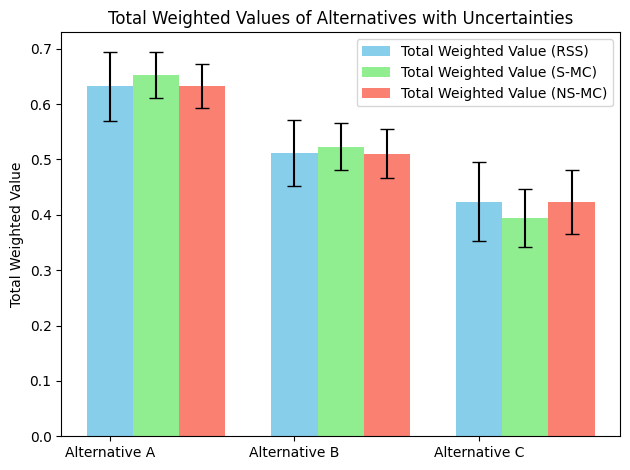

In [13]:
import matplotlib.pyplot as plt

for i, r_rss in enumerate(results_MC_RSS):
    print(f"Alternative {chr(65+results_MC_RSS.index(r_rss))}: Total Weighted Value (RSS) = {r_rss}")
    print(f"Alternative {chr(65+i)}: Total Weighted Value (S-MC) = {np.mean(results_MC_strict[:, i])} ± {np.std(results_MC_strict[:, i])}")
    print(f"Alternative {chr(65+i)}: Total Weighted Value (NS-MC) = {np.mean(results_MC_non_strict[:, i])} ± {np.std(results_MC_non_strict[:, i])}")
    
labels = [f"Alternative {chr(65+i)}" for i in range(len(alternatives))]
values_rss = [res.value for res in results_MC_RSS]
values_smc = [np.mean(results_MC_strict[:, i]) for i in range(results_MC_strict.shape[1])]
values_nsmc = [np.mean(results_MC_non_strict[:, i]) for i in range(results_MC_non_strict.shape[1])]
uncertainties_rss = [res.uncertainty for res in results_MC_RSS]
uncertainties_smc = [np.std(results_MC_strict[:, i]) for i in range(results_MC_strict.shape[1])]
uncertainties_nsmc = [np.std(results_MC_non_strict[:, i]) for i in range(results_MC_non_strict.shape[1])]
x = np.arange(len(labels))
width = 0.25
fig, ax = plt.subplots()
bars_rss = ax.bar(x, values_rss, width, yerr=uncertainties_rss, capsize=5, label='Total Weighted Value (RSS)', color='skyblue', ecolor='black')
bars_smc = ax.bar(x + width, values_smc, width, yerr=uncertainties_smc, capsize=5, label='Total Weighted Value (S-MC)', color='lightgreen', ecolor='black')
bars_nsmc = ax.bar(x + 2*width, values_nsmc, width, yerr=uncertainties_nsmc, capsize=5, label='Total Weighted Value (NS-MC)', color='salmon', ecolor='black')
ax.set_ylabel('Total Weighted Value')
ax.set_title('Total Weighted Values of Alternatives with Uncertainties')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()
plt.tight_layout()
plt.show()

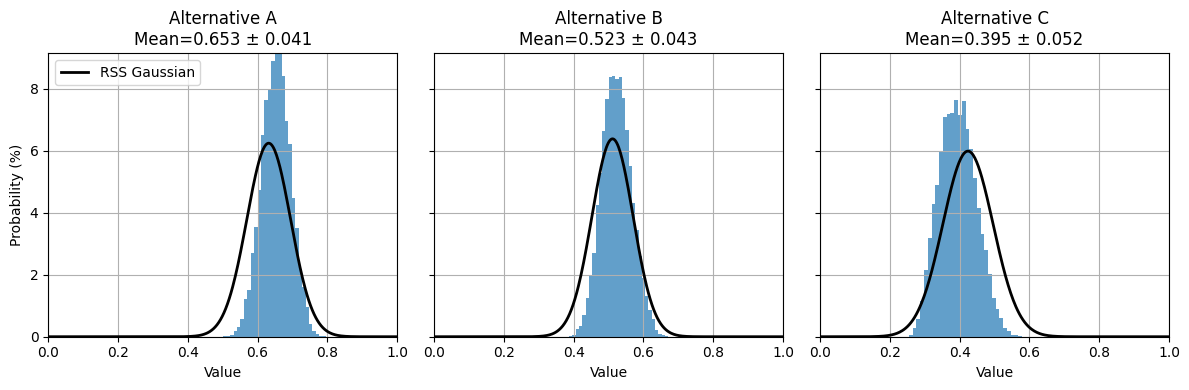

In [14]:
# plot all alternatives in one figure using subplots and overlay RSS as Gaussians
n = len(alternatives)
fig, axes = plt.subplots(1, n, figsize=(4 * n, 4), sharey=True)
if n == 1:
    axes = [axes]

# prepare RSS stats
rss_means = [m.value for m in results_MC_RSS]
rss_sigmas = [m.uncertainty for m in results_MC_RSS]

for alt_idx, ax in enumerate(axes):
    # for strict results each run has two values per alternative, so average across last axis per run
    if results_MC_strict.ndim == 3:
        data = np.mean(results_MC_strict[:, alt_idx, :], axis=1)
    else:
        data = results_MC_strict[:, alt_idx]

    hist, bin_edges = np.histogram(data, bins=30)
    hist_prob = hist / sim_runs  # probability per bin (sums to 1)
    mean_value = np.mean(data)
    std_value = np.std(data)

    ax.bar(bin_edges[:-1], hist_prob * 100, width=np.diff(bin_edges), align='edge', alpha=0.7)
    ax.set_xlabel("Value")
    ax.set_xlim(0, 1)
    ax.set_ylabel("Probability (%)" if alt_idx == 0 else "")
    ax.set_title(f"Alternative {chr(65 + alt_idx)}\nMean={mean_value:.3f} ± {std_value:.3f}")
    ax.grid(True)
    ax.set_ylim(0, max(hist_prob * 100) * 1.2)

    # overlay RSS as Gaussian (scaled to match histogram percentage per bin)
    mean_rss = rss_means[alt_idx]
    sigma_rss = rss_sigmas[alt_idx]
    bin_width = np.mean(np.diff(bin_edges))
    x_pdf = np.linspace(0, 1, 400)
    # avoid div by zero if sigma is zero
    if sigma_rss <= 0:
        ax.axvline(mean_rss, color='k', linestyle='--', label='RSS (mean)')
    else:
        pdf = np.exp(-0.5 * ((x_pdf - mean_rss) / sigma_rss) ** 2) / (sigma_rss * np.sqrt(2 * np.pi))
        # scale pdf to percentage per bin to match bar heights
        pdf_scaled = pdf * 100 * bin_width
        ax.plot(x_pdf, pdf_scaled, color='black', lw=2, label='RSS Gaussian')

# add a single legend
handles, labels = axes[0].get_legend_handles_labels()
if handles:
    axes[0].legend()

plt.tight_layout()
plt.show()

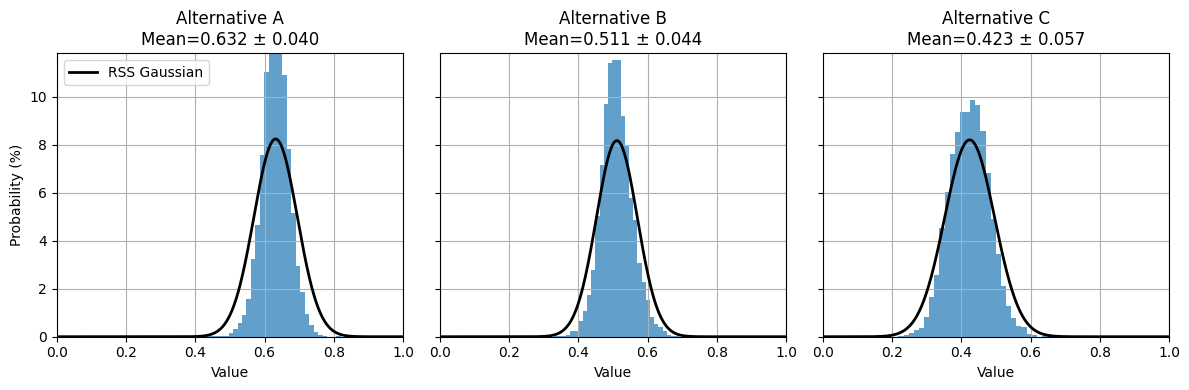

In [15]:
# plot all alternatives in one figure using subplots and overlay RSS as Gaussians
n = len(alternatives)
fig, axes = plt.subplots(1, n, figsize=(4 * n, 4), sharey=True)
if n == 1:
    axes = [axes]

# prepare RSS stats
rss_means = [m.value for m in results_MC_RSS]
rss_sigmas = [m.uncertainty for m in results_MC_RSS]

for alt_idx, ax in enumerate(axes):
    # for strict results each run has two values per alternative, so average across last axis per run
    if results_MC_non_strict.ndim == 3:
        data = np.mean(results_MC_non_strict[:, alt_idx, :], axis=1)
    else:
        data = results_MC_non_strict[:, alt_idx]

    hist, bin_edges = np.histogram(data, bins=30)
    hist_prob = hist / sim_runs  # probability per bin (sums to 1)
    mean_value = np.mean(data)
    std_value = np.std(data)

    ax.bar(bin_edges[:-1], hist_prob * 100, width=np.diff(bin_edges), align='edge', alpha=0.7)
    ax.set_xlabel("Value")
    ax.set_xlim(0, 1)
    ax.set_ylabel("Probability (%)" if alt_idx == 0 else "")
    ax.set_title(f"Alternative {chr(65 + alt_idx)}\nMean={mean_value:.3f} ± {std_value:.3f}")
    ax.grid(True)
    ax.set_ylim(0, max(hist_prob * 100) * 1.2)

    # overlay RSS as Gaussian (scaled to match histogram percentage per bin)
    mean_rss = rss_means[alt_idx]
    sigma_rss = rss_sigmas[alt_idx]
    bin_width = np.mean(np.diff(bin_edges))
    x_pdf = np.linspace(0, 1, 400)
    # avoid div by zero if sigma is zero
    if sigma_rss <= 0:
        ax.axvline(mean_rss, color='k', linestyle='--', label='RSS (mean)')
    else:
        pdf = np.exp(-0.5 * ((x_pdf - mean_rss) / sigma_rss) ** 2) / (sigma_rss * np.sqrt(2 * np.pi))
        # scale pdf to percentage per bin to match bar heights
        pdf_scaled = pdf * 100 * bin_width
        ax.plot(x_pdf, pdf_scaled, color='black', lw=2, label='RSS Gaussian')

# add a single legend
handles, labels = axes[0].get_legend_handles_labels()
if handles:
    axes[0].legend()

plt.tight_layout()
plt.show()

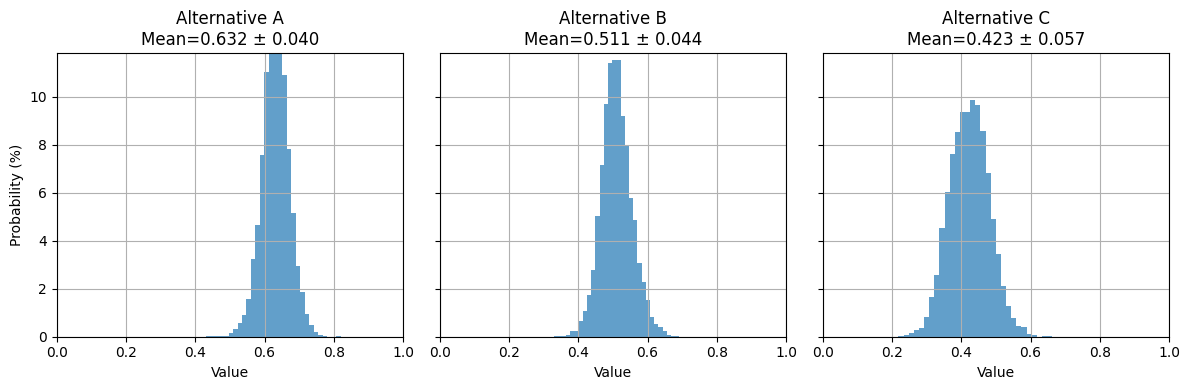

In [16]:

# plot all alternatives in one figure using subplots
n = len(alternatives)
fig, axes = plt.subplots(1, n, figsize=(4 * n, 4), sharey=True)
if n == 1:
    axes = [axes]

for alt_idx, ax in enumerate(axes):
    # for strict results each run has two values per alternative, so average across last axis per run
    if results_MC_non_strict.ndim == 3:
        data = np.mean(results_MC_non_strict[:, alt_idx, :], axis=1)
    else:
        data = results_MC_non_strict[:, alt_idx]

    hist, bin_edges = np.histogram(data, bins=30)
    hist_prob = hist / sim_runs  # probability per bin (sums to 1)
    mean_value = np.mean(data)
    std_value = np.std(data)

    ax.bar(bin_edges[:-1], hist_prob * 100, width=np.diff(bin_edges), align='edge', alpha=0.7)
    ax.set_xlabel("Value")
    ax.set_xlim(0, 1)
    ax.set_ylabel("Probability (%)" if alt_idx == 0 else "")
    ax.set_title(f"Alternative {chr(65 + alt_idx)}\nMean={mean_value:.3f} ± {std_value:.3f}")
    ax.grid(True)
    ax.set_ylim(0, max(hist_prob * 100) * 1.2)

plt.tight_layout()
plt.show()